In [1]:
import statistics as st
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

road_traffic_df = pd.read_csv('traffic-prediction-dataset.csv')
road_traffic_df.columns = ['Cross 1', 'Cross 2','Cross 3','Cross 4','Cross 5','Cross 6']

# Zeigt die ersten 5 Zeilen an
print(road_traffic_df.head())
print(road_traffic_df.index)

   Cross 1  Cross 2  Cross 3  Cross 4  Cross 5  Cross 6
0    105.0     48.0       30     62.0       31    110.0
1     97.0     41.0       32     55.0       42    103.0
2     76.0     47.0       44     58.0       40    100.0
3     98.0     40.0       39     59.0       43    104.0
4     87.0     41.0       47     49.0       35    112.0
RangeIndex(start=0, stop=16128, step=1)


## Aufgabe a

In [2]:
cols = ['Cross 1', 'Cross 2','Cross 3','Cross 4','Cross 5','Cross 6']
rows_lage = ['Mittelwert', 'Median', 'Modus', 'Quantil25', 'Quantil50', 'Quantil75']
rows_streuung = ['Varianz', 'Standardabweichung', 'Spannweite']

# Erzeugt die leere Struktur automatisch
lage = {r: {c: 'value' for c in cols} for r in rows_lage}

boxplot = {c: 'value' for c in cols}

streuung = {r: {c: 'value' for c in cols} for r in rows_streuung}

# Berechnung von Werten: Mittelwerte, Mediane, Modi, Standardabweichungen, Quantile, Spannweiten, Varianzen
for i in (road_traffic_df):
    col = road_traffic_df.loc[:, i]

    lage['Mittelwert'][i] = col.mean()
    lage['Median'][i] = col.median()
    lage['Modus'][i] = col.mode().iloc[0]
    streuung['Varianz'][i] = np.var(col)
    streuung['Standardabweichung'][i] = st.stdev(col)
    streuung['Spannweite'][i] = max(col) - min(col)
    lage['Quantil25'][i] = np.quantile(col, 0.25)
    lage['Quantil50'][i] = np.quantile(col, 0.50)
    lage['Quantil75'][i] = np.quantile(col, 0.75)
    boxplot[i] = col

# Werte als DataFrames
lage_df = pd.DataFrame(lage)
streuung_df = pd.DataFrame(streuung)
boxplot_df = pd.DataFrame(boxplot)

print(road_traffic_df.columns.tolist())
print(lage_df)
print(streuung_df)
print(boxplot_df)


['Cross 1', 'Cross 2', 'Cross 3', 'Cross 4', 'Cross 5', 'Cross 6']
         Mittelwert  Median  Modus  Quantil25  Quantil50  Quantil75
Cross 1   95.806207    88.0    0.0        8.0       88.0      169.0
Cross 2   45.948444    29.0    0.0        2.0       29.0       77.0
Cross 3   41.510355    32.0    0.0        1.0       32.0       73.0
Cross 4   67.656870    45.0    0.0        0.0       45.0      124.0
Cross 5   36.232453    28.0    0.0        1.0       28.0       60.0
Cross 6   76.215185    66.0    0.0        5.0       66.0      139.0
             Varianz  Standardabweichung  Spannweite
Cross 1  7670.957282           87.586717       352.5
Cross 2  2587.092999           50.865051       302.0
Cross 3  1751.278911           41.849582       218.0
Cross 4  4696.911311           68.536141       312.0
Cross 5  1396.613562           37.372452       193.0
Cross 6  4637.566558           68.101792       253.0
       Cross 1  Cross 2  Cross 3  Cross 4  Cross 5  Cross 6
0        105.0     48.0   

## Lageparameter

Text(0, 0.5, 'Werte')

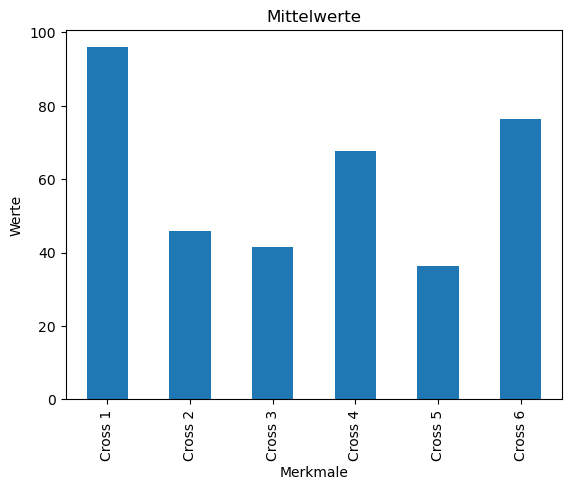

In [3]:
# Barplot Mittelwerte
lage_df.loc[:, 'Mittelwert'].plot.bar()

plt.title("Mittelwerte")
plt.xlabel("Merkmale")
plt.ylabel("Werte")

<Figure size 10000x20000 with 0 Axes>

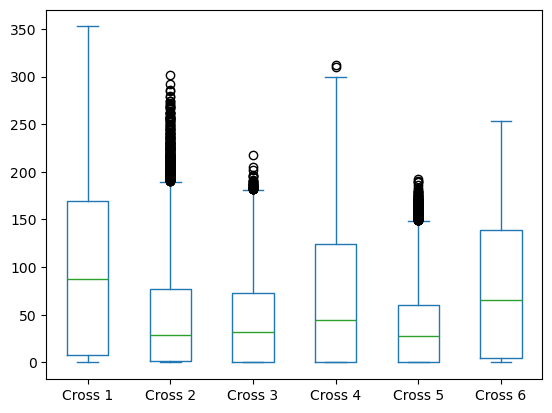

<Figure size 10000x20000 with 0 Axes>

In [4]:
# Boxplot der Originalwerte
boxplot_df.plot.box(autorange=True, zorder=2)

plt.figure(figsize=(100,200))
#plt.title("Mittelwerte")
#plt.xlabel("Merkmale")
#plt.ylabel("Werte")

Text(0, 0.5, 'Werte')

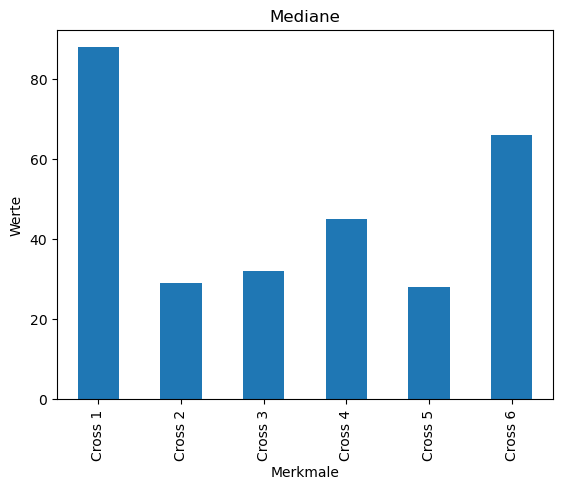

In [5]:
# Barplot Mediane
lage_df.loc[:, 'Median'].plot.bar()

plt.title("Mediane")
plt.xlabel("Merkmale")
plt.ylabel("Werte")

Text(0, 0.5, 'Werte')

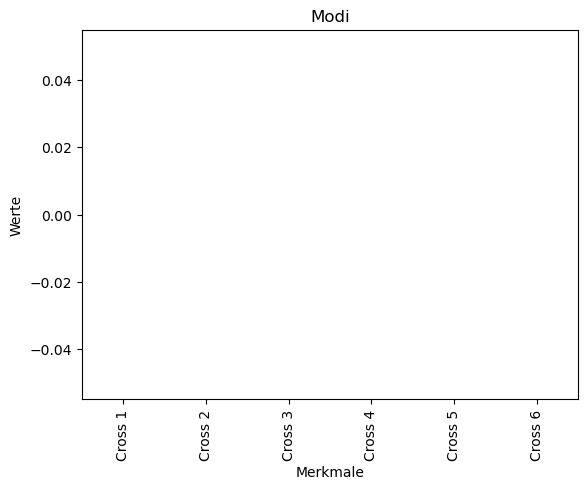

In [6]:
# Barplot Modi
lage_df.loc[:, 'Modus'].plot.bar()

plt.title("Modi")
plt.xlabel("Merkmale")
plt.ylabel("Werte")

In [7]:
# Berechnung kleinster Abweichungen der Lagewerte
result = []
for index in lage_df.columns :
    values = lage_df[index].values
    variablenames = lage_df.index.tolist()
    diffrences_matrix = np.abs(values[:,None] - values)
    np.fill_diagonal(diffrences_matrix,np.nan)
    min_diff = np.nanmin(diffrences_matrix)
    idx = np.where(diffrences_matrix == min_diff)
    var1 = variablenames[idx[0][0]]
    var2 = variablenames[idx[1][0]]
    
    result.append({
        "Kennzahl": index,
        "Kleinste Differenz": min_diff,
        "Variablenpaar": f"{var1} – {var2}"
    })
    result_df = pd.DataFrame(result)
    
print(result_df)

     Kennzahl  Kleinste Differenz      Variablenpaar
0  Mittelwert            4.438089  Cross 2 – Cross 3
1      Median            1.000000  Cross 2 – Cross 5
2       Modus            0.000000  Cross 1 – Cross 2
3   Quantil25            0.000000  Cross 3 – Cross 5
4   Quantil50            1.000000  Cross 2 – Cross 5
5   Quantil75            4.000000  Cross 2 – Cross 3


## Streuungsparameter

Text(0, 0.5, 'Werte')

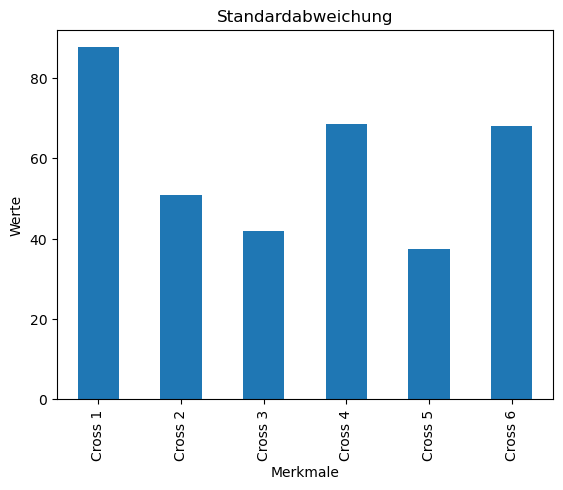

In [8]:
# Barplot Standardabweichungen
streuung_df.loc[:, 'Standardabweichung'].plot.bar()

plt.title("Standardabweichung")
plt.xlabel("Merkmale")
plt.ylabel("Werte")

Text(0, 0.5, 'Werte')

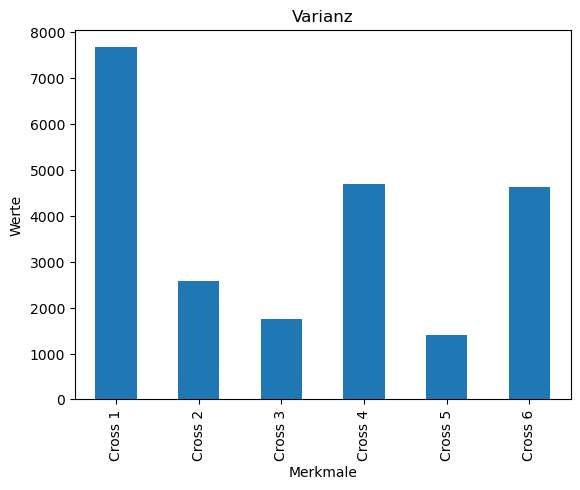

In [9]:
#Barplot Varianzen
streuung_df.loc[:, 'Varianz'].plot.bar()

plt.title("Varianz")
plt.xlabel("Merkmale")
plt.ylabel("Werte")

Text(0, 0.5, 'Werte')

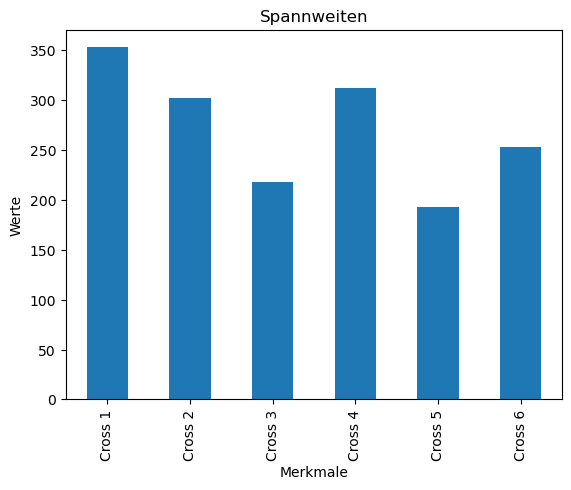

In [10]:
# Barplot Spannweiten
streuung_df.loc[:, 'Spannweite'].plot.bar()

plt.title("Spannweiten")
plt.xlabel("Merkmale")
plt.ylabel("Werte")

In [11]:
# Berechnung kleinster Abweichungen der Streuungswerte
result = []
for index in streuung_df.columns :
    values = streuung_df[index].values
    variablenames = streuung_df.index.tolist()
    diffrences_matrix = np.abs(values[:,None] - values)
    np.fill_diagonal(diffrences_matrix,np.nan)
    min_diff = np.nanmin(diffrences_matrix)
    idx = np.where(diffrences_matrix == min_diff)
    var1 = variablenames[idx[0][0]]
    var2 = variablenames[idx[1][0]]
    result.append({
        "Kennzahl": index,
        "Kleinste Differenz": min_diff,
        "Variablenpaar": f"{var1} – {var2}"
    })
    result_df = pd.DataFrame(result)
print(result_df)

             Kennzahl  Kleinste Differenz      Variablenpaar
0             Varianz           59.344752  Cross 4 – Cross 6
1  Standardabweichung            0.434348  Cross 4 – Cross 6
2          Spannweite           10.000000  Cross 2 – Cross 4


## Aufgabe b

<Figure size 10000x20000 with 0 Axes>

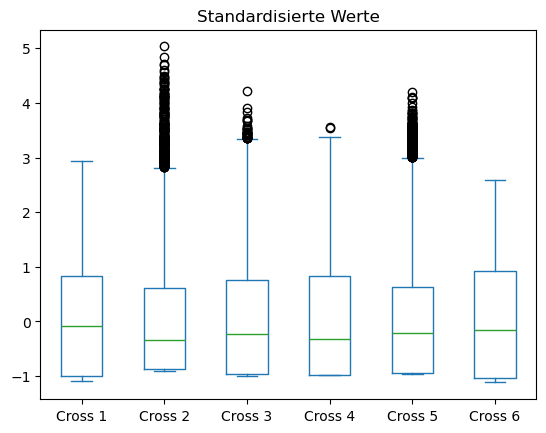

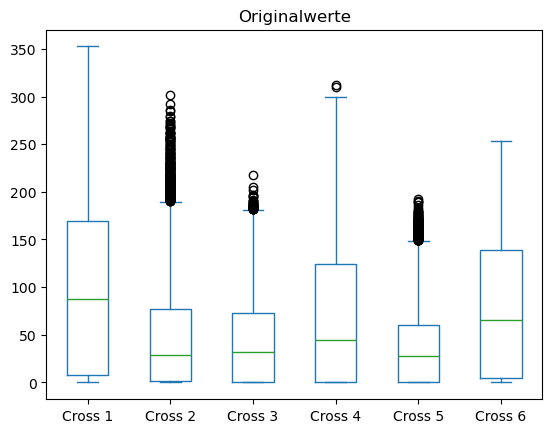

<Figure size 10000x20000 with 0 Axes>

In [12]:
# Werte standardisieren
z_standardisiert = pd.DataFrame([])

cols = list(road_traffic_df)
for col in cols:
    col_z = col
    z_standardisiert[col_z] = (road_traffic_df[col] - road_traffic_df[col].mean())/road_traffic_df[col].std(ddof=0)

# Boxplot z-Standardisiert
z_standardisiert.plot.box(autorange=True, zorder=2)
plt.title("Standardisierte Werte")

# Boxplot Originalwerte
road_traffic_df.plot.box(autorange=True, zorder=2)
plt.title("Originalwerte")

plt.figure(figsize=(100,200))

## Aufgabe c

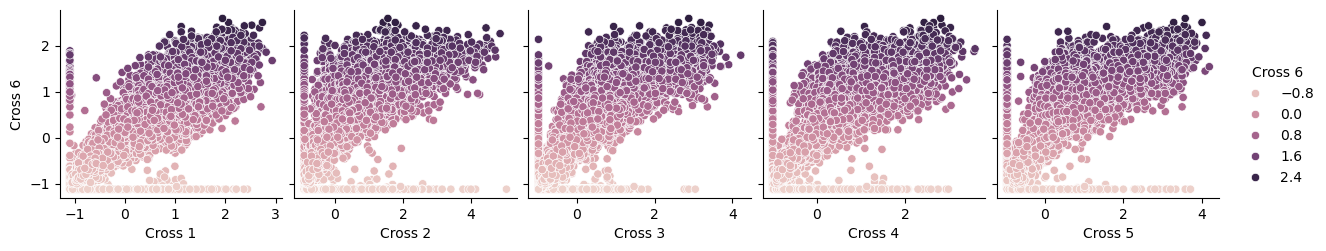

In [13]:
import seaborn

# Pairplot z-standartisierte Werte auf Cross 6
seaborn.pairplot(z_standardisiert, hue='Cross 6', y_vars='Cross 6')

## Aufgabe d

In [14]:
# Korrelationswerte berechnet
z_standardisiert.corrwith(z_standardisiert['Cross 6'])

Cross 1    0.907431
Cross 2    0.786556
Cross 3    0.859204
Cross 4    0.821113
Cross 5    0.812489
Cross 6    1.000000
dtype: float64